In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

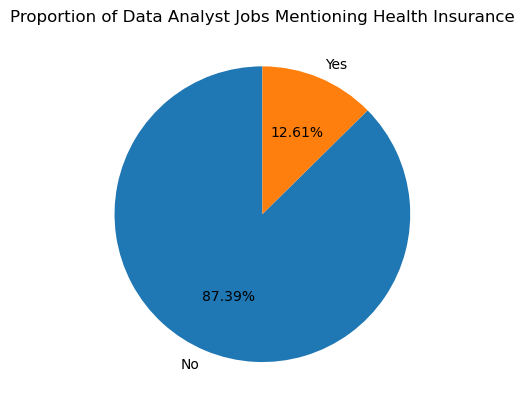

In [11]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
plt.pie(df_DA['job_health_insurance'].value_counts(), startangle=90, labels=['No', 'Yes'], autopct='%1.2f%%')
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')
plt.show()

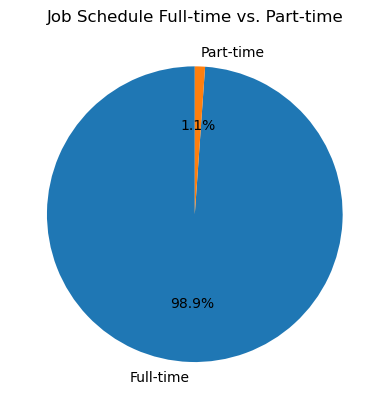

In [28]:
df_ft_pt = df[df['job_schedule_type'].isin(['Full-time', 'Part-time'])].copy()
schedule_counts = df_ft_pt['job_schedule_type'].value_counts()

plt.pie(schedule_counts, startangle=90, labels=schedule_counts.index, autopct='%1.1f%%')
plt.title('Job Schedule Full-time vs. Part-time')
plt.show()

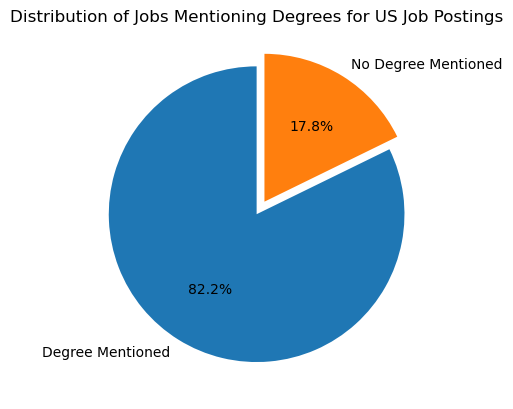

In [40]:
df_US = df[df['job_country'] == 'United States'].copy()
degree_mention_counts = df_US['job_no_degree_mention'].value_counts()
plt.pie(degree_mention_counts, labels=['Degree Mentioned', 'No Degree Mentioned'], startangle=90, autopct='%1.1f%%', explode=(0, 0.1))
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()